# 3.1 — Black-Scholes: derivación por réplica (PDE) y por martingalas

## Motivación

En 2.4 vimos que el precio del árbol CRR converge, cuando $n\to\infty$, a una fórmula cerrada — la usamos ahí como un límite dado, sin derivarla. Este notebook cierra esa deuda: obtenemos la fórmula de Black-Scholes (1973) **desde cero**, por **dos** caminos independientes que deben (y van a) coincidir exactamente.

La **primera** derivación es la original de Black, Scholes y Merton: construir un portafolio autofinanciado que replica al derivado y elimina todo riesgo instantáneo (el argumento de no-arbitraje de 2.1/2.3, ahora en tiempo continuo con Itô, 1.3), lo que produce una PDE parabólica; resolvemos esa PDE reduciéndola, mediante una secuencia de cambios de variable, a la ecuación del calor clásica. La **segunda** es la derivación moderna vía la medida neutral al riesgo $\mathbb{Q}$ (Girsanov y cambio de numerario, 1.5; FTAP, 2.3): el precio es una esperanza descontada, $V_0=e^{-rT}\mathbb{E}^{\mathbb{Q}}[(S_T-K)^+]$, que calculamos como una integral lognormal explícita — truncada en el umbral $d_2$ y resuelta completando el cuadrado. Ambas derivaciones son completas y ambas terminan en la misma fórmula cerrada con $d_1,d_2$; el hecho de que un argumento de cobertura dinámica (PDE) y un argumento de esperanza bajo una medida abstracta ($\mathbb{Q}$) coincidan es, en sí mismo, el contenido del Teorema Fundamental de Asset Pricing (2.3) en tiempo continuo.

Cubrimos: (i) derivación 1 — réplica y PDE, reducción a la ecuación del calor; (ii) derivación 2 — martingala, cálculo completo de la esperanza lognormal; (iii) paridad put-call e interpretación probabilística de $N(d_1)$ y $N(d_2)$; (iv) implementación de `bs_price` y demos (superficie de precio, verificación Monte Carlo, paridad numérica); (v) validación contra `QuantLib` (`AnalyticEuropeanEngine`) en una malla de strikes y vencimientos, $\text{atol}=10^{-10}$.

## 0. Modelo

Trabajamos con el modelo canónico de Black-Scholes-Merton: un activo $S_t$ que sigue un movimiento browniano geométrico (01.4) bajo la medida física $\mathbb{P}$,
$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t, \qquad S_0 > 0,
$$
con $\mu$ la tasa de rendimiento esperada y $\sigma>0$ la volatilidad, ambas constantes; una cuenta de mercado de dinero $B_t$ con $dB_t = rB_t\,dt$ ($r$ constante, libre de riesgo); y mercados sin fricciones (sin costos de transacción, trading continuo, venta en corto permitida, activos infinitamente divisibles). Queremos el precio $V_0$ de una opción europea con payoff $\Phi(S_T)$ a vencimiento $T$ — el caso canónico es el call, $\Phi(S_T)=(S_T-K)^+$.

Por simplicidad las dos derivaciones que siguen asumen **sin dividendos**; es el caso original de Black-Scholes (1973). La generalización a un rendimiento por dividendos continuo $q$ (Merton, 1973) — que es la que implementamos en `bs_price` y en `qflib.black` — se obtiene reemplazando $S_0\to S_0e^{-qT}$ (el "cost of carry" $b=r-q$) por el mismo argumento de réplica financiando la posición en acciones con reinversión continua de dividendos; lo señalamos como observación al final de la Sección 1 sin rehacer la PDE completa.

## 1. Derivación 1 — Réplica y PDE

### 1.1 Portafolio autofinanciado y eliminación del riesgo

Sea $V(S,t)$ el valor (aún desconocido) de la opción en el tiempo $t$, dos veces diferenciable en $S$ y una vez en $t$. Por el lema de Itô (1.3) aplicado a $V(S_t,t)$:
$$
dV = \left(V_t + \mu S V_S + \tfrac{1}{2}\sigma^2 S^2 V_{SS}\right)dt + \sigma S V_S\, dW_t.
$$

Construimos un portafolio $\Pi_t$ **corto** una opción y **largo** $\Delta_t$ acciones, autofinanciado (cualquier cambio de valor viene solo de $dS$ y $dV$, sin inyecciones ni retiros de efectivo):
$$
\Pi_t = -V_t^{(\text{valor})} + \Delta_t S_t \quad\text{(abuso de notación: "$V_t^{(\text{valor})}$" es $V(S_t,t)$, no $\partial V/\partial t$)}.
$$
Su variación instantánea es
$$
d\Pi_t = -dV + \Delta_t\, dS_t = -\left(V_t + \mu S V_S + \tfrac{1}{2}\sigma^2 S^2 V_{SS}\right)dt - \sigma S V_S\, dW_t + \Delta_t\big(\mu S\,dt + \sigma S\,dW_t\big).
$$
Agrupando por $dt$ y $dW_t$:
$$
d\Pi_t = \Big[-V_t - \tfrac{1}{2}\sigma^2 S^2 V_{SS} + \mu S(\Delta_t - V_S)\Big]dt + \sigma S(\Delta_t - V_S)\,dW_t.
$$
El término estocástico ($dW_t$) es el único riesgo del portafolio. Si elegimos
$$
\boxed{\Delta_t = V_S(S_t,t)}
$$
lo eliminamos por completo — **esta es la razón de ser del delta-hedging** (03.2 lo explota numéricamente): con esa elección, $\Delta_t - V_S = 0$ y también desaparece el término $\mu S(\Delta_t-V_S)$, dejando
$$
d\Pi_t = \left(-V_t - \tfrac{1}{2}\sigma^2 S^2 V_{SS}\right)dt,
$$
un portafolio **instantáneamente sin riesgo**: su rendimiento en $[t,t+dt]$ es determinista.

### 1.2 No-arbitraje: la PDE de Black-Scholes

Un portafolio sin riesgo debe rendir exactamente la tasa libre de riesgo — si rindiera más, un arbitrajista pediría prestado a $r$ para comprarlo; si rindiera menos, lo vendería en corto e invertiría a $r$ (el mismo argumento de no-arbitraje de 2.1/2.3, ahora aplicado a una cobertura dinámica en vez de una réplica estática de un periodo). Entonces
$$
d\Pi_t = r\,\Pi_t\, dt = r\big(-V + S V_S\big)\,dt.
$$
Igualando con la expresión de la sección anterior:
$$
-V_t - \tfrac{1}{2}\sigma^2 S^2 V_{SS} = r\big(S V_S - V\big) \quad\Longrightarrow\quad
$$
$$
\boxed{V_t + rS V_S + \tfrac{1}{2}\sigma^2 S^2 V_{SS} - rV = 0}, \qquad 0 \leq t < T,\ S>0.
$$

Esta es la **PDE de Black-Scholes**. Dos observaciones importantes: (i) $\mu$ — el rendimiento esperado bajo $\mathbb{P}$ — **desapareció por completo**; el precio no depende de las preferencias de riesgo ni de la tasa de crecimiento real del activo, solo de $r$ y $\sigma$. Esto ya anticipa la derivación 2: la PDE es *exactamente* la ecuación de Feynman-Kac para $\mathbb{E}^{\mathbb{Q}}[e^{-r(T-t)}\Phi(S_T)\mid S_t=S]$ bajo una dinámica $dS=rS\,dt+\sigma S\,dW^{\mathbb{Q}}$ — la PDE **es** la esperanza bajo $\mathbb{Q}$, escrita en forma diferencial. (ii) La condición terminal es el payoff,
$$
V(S,T) = \Phi(S) = (S-K)^+ \quad\text{(call)},
$$
con condiciones de frontera $V(0,t)=0$ (si $S$ llega a 0 se queda en 0, GBM absorbente) y $V(S,t)\to S - Ke^{-r(T-t)}$ cuando $S\to\infty$ (delta $\to 1$, la opción se comporta como el forward).

### 1.3 Solución vía reducción a la ecuación del calor

La PDE tiene coeficientes que dependen de $S$ ($rS\,V_S$, $\sigma^2S^2V_{SS}$) — no es todavía una ecuación de coeficientes constantes. La resolvemos con una secuencia de tres cambios de variable, cada uno eliminando un obstáculo distinto.

**Paso 1 — log-precio y tiempo a vencimiento.** Sea $\tau = T-t$ (tiempo restante) y $x=\ln(S/K)$ (log-moneyness). Con $V(S,t)=v(x,\tau)$, la regla de la cadena da $SV_S = v_x$ y $S^2V_{SS}=v_{xx}-v_x$ (identidades estándar de $\partial_S = \tfrac{1}{S}\partial_x$), y $V_t=-v_\tau$. Sustituyendo en la PDE:
$$
v_\tau = \tfrac{1}{2}\sigma^2 v_{xx} + \left(r-\tfrac{1}{2}\sigma^2\right)v_x - rv.
$$
Ya son coeficientes **constantes**, pero quedan un término de convección ($v_x$) y uno de reacción/descuento ($-rv$).

**Paso 2 — quitar el descuento.** Sea $w(x,\tau)=e^{r\tau}v(x,\tau)$ (deshacer el descuento). Entonces $w_\tau = e^{r\tau}(v_\tau+rv) = e^{r\tau}\left[\tfrac{1}{2}\sigma^2v_{xx}+(r-\tfrac12\sigma^2)v_x\right] = \tfrac12\sigma^2w_{xx}+(r-\tfrac12\sigma^2)w_x$: el término $-rv$ se cancela exactamente y queda
$$
w_\tau = \tfrac{1}{2}\sigma^2 w_{xx} + \left(r-\tfrac{1}{2}\sigma^2\right)w_x.
$$
(Esto no es casualidad: $w=e^{r\tau}V$ es el valor *no descontado*, y su ecuación es la de un proceso de difusión puro con drift $r-\tfrac12\sigma^2$ — precisamente el drift del log-precio bajo $\mathbb{Q}$ que usaremos en la Sección 2.)

**Paso 3 — quitar la convección.** Sea $y = x + \left(r-\tfrac12\sigma^2\right)\tau$: un cambio de variable que "viaja" junto con el drift (transformación galileana). Con $z(y,\tau)=w(x,\tau)$, la regla de la cadena da $w_x = z_y$ y $w_\tau\big|_x = z_\tau + \left(r-\tfrac12\sigma^2\right)z_y$ (porque $\partial y/\partial\tau|_x = r-\tfrac12\sigma^2$). Sustituyendo:
$$
z_\tau + \left(r-\tfrac12\sigma^2\right)z_y = \tfrac12\sigma^2 z_{yy} + \left(r-\tfrac12\sigma^2\right)z_y \quad\Longrightarrow\quad \boxed{z_\tau = \tfrac{1}{2}\sigma^2 z_{yy}}.
$$

Es la **ecuación del calor** con coeficiente de difusión $D=\tfrac12\sigma^2$. La condición inicial (en $\tau=0$, i.e. $t=T$, donde $y=x$) es $z(y,0)=g(y):=\Phi(Ke^y)=K(e^y-1)^+$ para el call.

**Solución por el núcleo del calor.** La solución de $z_\tau=Dz_{yy}$ con dato inicial $g$ es la convolución con el núcleo gaussiano de varianza $2D\tau=\sigma^2\tau$:
$$
z(y,\tau) = \int_{-\infty}^{\infty} g(y')\,\frac{1}{\sqrt{2\pi\sigma^2\tau}}\exp\!\left(-\frac{(y-y')^2}{2\sigma^2\tau}\right)dy'
= K\int_0^{\infty}(e^{y'}-1)\,\varphi_{y,\sigma^2\tau}(y')\,dy',
$$
donde $\varphi_{y,\sigma^2\tau}$ es la densidad $N(y,\sigma^2\tau)$ y el límite inferior $0$ viene de que $g(y')=0$ para $y'\leq 0$ — el mismo tipo de **integral gaussiana truncada** que resolvemos en detalle completo en la Sección 2 (completar el cuadrado en el término $e^{y'}$, evaluar la cola con $N(\cdot)$). Aplicando esa técnica aquí:
$$
z(y,\tau) = K\Big[e^{y+\frac12\sigma^2\tau}\,N\!\Big(\frac{y+\sigma^2\tau}{\sigma\sqrt\tau}\Big) - N\!\Big(\frac{y}{\sigma\sqrt\tau}\Big)\Big].
$$

**Deshaciendo los tres cambios de variable.** Con $y=x+(r-\tfrac12\sigma^2)\tau=\ln(S/K)+(r-\tfrac12\sigma^2)\tau$, se identifica $y/(\sigma\sqrt\tau)=d_2$ y $(y+\sigma^2\tau)/(\sigma\sqrt\tau)=d_1$ con las definiciones estándar (Sección 2), y $e^{y+\frac12\sigma^2\tau}=(S/K)e^{r\tau}$. Entonces
$$
z(y,\tau) = K\left[\frac{S}{K}e^{r\tau}N(d_1) - N(d_2)\right] = Se^{r\tau}N(d_1) - KN(d_2),
$$
y deshaciendo el Paso 2 ($V=e^{-r\tau}w=e^{-r\tau}z$) con $\tau=T$ en $t=0$:
$$
\boxed{V_0 = S_0\,N(d_1) - Ke^{-rT}N(d_2)}
$$
— la fórmula de Black-Scholes, obtenida enteramente por réplica y reducción de PDE, sin invocar ninguna medida de probabilidad más allá de la $\mathbb{P}$ original que define el GBM. La Sección 2 llega al mismo resultado por un camino conceptualmente distinto.

## 2. Derivación 2 — Martingala (esperanza bajo $\mathbb{Q}$)

### 2.1 Precio como esperanza descontada

Por Girsanov (1.5), existe una medida $\mathbb{Q}\sim\mathbb{P}$ (la medida neutral al riesgo, con numerario $B_t=e^{rt}$) bajo la cual
$$
dS_t = rS_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}},
$$
y el precio de cualquier derivado europeo es la esperanza de su payoff descontado bajo $\mathbb{Q}$ (FTAP, 2.3, extendido a tiempo continuo vía la propiedad de martingala de $S_t/B_t$):
$$
V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[(S_T-K)^+\big].
$$
La solución de la SDE (01.4, GBM) da la distribución lognormal exacta de $S_T$:
$$
S_T = S_0\exp\!\left[\left(r-\tfrac12\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \qquad Z\sim N(0,1)\ \text{bajo}\ \mathbb{Q}.
$$

### 2.2 Cálculo completo de la esperanza lognormal

Descomponemos $(S_T-K)^+=(S_T-K)\mathbb{1}_{\{S_T>K\}}$, así que
$$
\mathbb{E}^{\mathbb{Q}}\big[(S_T-K)^+\big] = \mathbb{E}^{\mathbb{Q}}\big[S_T\,\mathbb{1}_{\{S_T>K\}}\big] - K\,\mathbb{Q}(S_T>K).
$$

**El umbral en $Z$ y el término $N(d_2)$.** El evento $\{S_T>K\}$ equivale a
$$
Z > \frac{\ln(K/S_0)-\left(r-\tfrac12\sigma^2\right)T}{\sigma\sqrt T} = -d_2, \qquad\text{donde}\qquad d_2 := \frac{\ln(S_0/K)+\left(r-\tfrac12\sigma^2\right)T}{\sigma\sqrt T}.
$$
Por simetría de la normal estándar, $\mathbb{Q}(Z>-d_2)=\mathbb{Q}(Z<d_2)=N(d_2)$, de modo que
$$
\mathbb{Q}(S_T>K) = N(d_2).
$$
Esta es la **integral truncada en $d_2$**: la cola de la normal estándar más allá de $-d_2$, que colapsa a $N(d_2)$ por simetría — sin necesidad de evaluarla numéricamente, ya es una CDF normal cerrada.

**El término $N(d_1)$: completar el cuadrado.** Para el primer término escribimos $S_T$ en función de $Z$ y sacamos las constantes de la integral:
$$
\mathbb{E}^{\mathbb{Q}}\big[S_T\,\mathbb{1}_{\{Z>-d_2\}}\big] = S_0\,e^{\left(r-\frac12\sigma^2\right)T}\int_{-d_2}^{\infty} e^{\sigma\sqrt{T}z}\,\frac{1}{\sqrt{2\pi}}e^{-z^2/2}\,dz.
$$
El integrando combina los dos exponentes en $z$:
$$
\sigma\sqrt{T}z - \tfrac12 z^2 = -\tfrac12\left(z^2-2\sigma\sqrt{T}z\right) = -\tfrac12\left(z-\sigma\sqrt{T}\right)^2 + \tfrac12\sigma^2T,
$$
que es exactamente **completar el cuadrado**: sumar y restar $\sigma^2T$ para escribir el exponente como un cuadrado perfecto centrado en $\sigma\sqrt T$ más una constante. Sustituyendo,
$$
\int_{-d_2}^{\infty} e^{\sigma\sqrt{T}z-\frac12z^2}\frac{dz}{\sqrt{2\pi}} = e^{\frac12\sigma^2T}\int_{-d_2}^{\infty}\frac{1}{\sqrt{2\pi}}e^{-\frac12(z-\sigma\sqrt T)^2}\,dz.
$$
El integrando restante es la densidad $N(\sigma\sqrt T,1)$; con el cambio de variable $u=z-\sigma\sqrt T$ (que traslada la normal a $N(0,1)$), el límite inferior se traslada a $-d_2-\sigma\sqrt T=-d_1$, definiendo
$$
d_1 := d_2+\sigma\sqrt T = \frac{\ln(S_0/K)+\left(r+\tfrac12\sigma^2\right)T}{\sigma\sqrt T},
$$
y la integral se cierra como otra CDF normal, de nuevo por simetría:
$$
\int_{-d_2}^{\infty}\frac{1}{\sqrt{2\pi}}e^{-\frac12(z-\sigma\sqrt T)^2}dz = \int_{-d_1}^{\infty}\frac{1}{\sqrt{2\pi}}e^{-u^2/2}du = N(d_1).
$$
Reuniendo todo:
$$
\mathbb{E}^{\mathbb{Q}}\big[S_T\,\mathbb{1}_{\{S_T>K\}}\big] = S_0\,e^{\left(r-\frac12\sigma^2\right)T}\cdot e^{\frac12\sigma^2T}\cdot N(d_1) = S_0\,e^{rT}N(d_1).
$$

### 2.3 La fórmula cerrada

Sustituyendo ambos términos:
$$
\mathbb{E}^{\mathbb{Q}}\big[(S_T-K)^+\big] = S_0e^{rT}N(d_1) - KN(d_2),
$$
y descontando,
$$
\boxed{V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}\big[(S_T-K)^+\big] = S_0\,N(d_1) - Ke^{-rT}N(d_2)},
$$
**idéntica** a la fórmula obtenida en la Sección 1 por réplica y PDE — dos derivaciones independientes, mismo resultado. Con dividendos continuos $q$ (Merton, 1973; lo que implementa `bs_price` más abajo), $S_t$ crece a tasa $r-q$ bajo $\mathbb{Q}$ y el resultado se generaliza reemplazando $S_0\to S_0e^{-qT}$ en $d_1,d_2$ y en el primer término:
$$
C = S_0e^{-qT}N(d_1) - Ke^{-rT}N(d_2), \qquad d_{1,2}=\frac{\ln(S_0/K)+\left(r-q\pm\tfrac12\sigma^2\right)T}{\sigma\sqrt T}.
$$

### 2.4 Paridad put-call e interpretación probabilística

**Paridad put-call.** Un portafolio largo un call y corto un put con el mismo $(K,T)$ replica exactamente un forward, $C-P=S_T-K$ en $T$ sin importar $S_T$ — un argumento de réplica **estático** (no requiere ningún modelo de $S_t$, a diferencia de las dos derivaciones anteriores). Descontando el payoff del forward, $C_0-P_0=S_0e^{-qT}-Ke^{-rT}$ para cualquier modelo consistente con no-arbitraje. Usando $N(-x)=1-N(x)$ en la fórmula del call se obtiene directamente la fórmula cerrada del put:
$$
P_0 = C_0 - S_0e^{-qT} + Ke^{-rT} = Ke^{-rT}N(-d_2) - S_0e^{-qT}N(-d_1).
$$

**Interpretación probabilística.** De la Sección 2.2, $N(d_2)=\mathbb{Q}(S_T>K)$: la probabilidad, bajo la medida neutral al riesgo, de que el call termine dentro del dinero — por eso $N(d_2)$ aparece con frecuencia como *"delta de riesgo neutral"* o proxy de la probabilidad de ejercicio. $N(d_1)$ tiene una lectura análoga pero bajo la **medida de la acción** $\mathbb{Q}^S$ (cambio de numerario de $B_t$ a $S_t$, 1.5 Sección 5): la derivada de Radon-Nikodym $d\mathbb{Q}^S/d\mathbb{Q}=S_T/(S_0e^{rT})$ es precisamente el factor que multiplica a $N(d_1)$ en el cálculo de 2.2, de modo que $N(d_1)=\mathbb{Q}^S(S_T>K)$: la probabilidad de ejercicio medida en unidades de la propia acción. Esto también explica por qué $\Delta=\partial C/\partial S_0=e^{-qT}N(d_1)$ (Sección 3): el delta de cobertura es la probabilidad de ejercicio bajo el numerario "natural" del activo que se está replicando.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)
from scipy.stats import norm

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0

## 3. Implementación

`bs_price` implementa la fórmula cerrada de las Secciones 1-2 (con dividendo continuo $q$, Merton 1973); `bs_delta` es $\partial C/\partial S_0=e^{-qT}N(d_1)$, usada en la interpretación probabilística de 2.4 y en la Demo 1. Ambas se promueven a `qflib.black` (con las demás griegas y `implied_vol`) en un commit separado, con su propia suite de tests contra `QuantLib`.

In [2]:
def _d1_d2(S, K, r, q, sigma, T):
    '''d1, d2 of the Black-Scholes-Merton formula (Sections 1-2).'''
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return d1, d2


def bs_price(S, K, r, q, sigma, T, kind="call"):
    '''Black-Scholes-Merton price of a European option (closed form).'''
    d1, d2 = _d1_d2(S, K, r, q, sigma, T)
    disc_r, disc_q = np.exp(-r * T), np.exp(-q * T)
    if kind == "call":
        return S * disc_q * norm.cdf(d1) - K * disc_r * norm.cdf(d2)
    else:
        return K * disc_r * norm.cdf(-d2) - S * disc_q * norm.cdf(-d1)


def bs_delta(S, K, r, q, sigma, T, kind="call"):
    '''dPrice/dS -- probability of exercise under the share measure (Sec 2.4).'''
    d1, _ = _d1_d2(S, K, r, q, sigma, T)
    disc_q = np.exp(-q * T)
    return disc_q * norm.cdf(d1) if kind == "call" else disc_q * (norm.cdf(d1) - 1.0)


# sanity check: canonical ATM call, both derivations agree by construction (same formula)
print(f"bs_price(S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}, 'call') = "
      f"{bs_price(S0, K, r, q, sigma, T, 'call'):.6f}")

bs_price(S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0, 'call') = 10.450584


## 4. Demo 1 — Superficie de precio vs $(S,T)$

Precio del call sobre una malla de spot $S\in[50,150]$ y madurez $T\in[0.05,3]$, $K=100$ fijo. La superficie debe ser creciente en $S$ (delta positivo) y, para un call ATM/OTM, generalmente creciente en $T$ (más tiempo = más valor óptico), aunque no monótonamente para todo $S$ profundamente ITM con dividendos — aquí $q=0$ así que sí lo es.

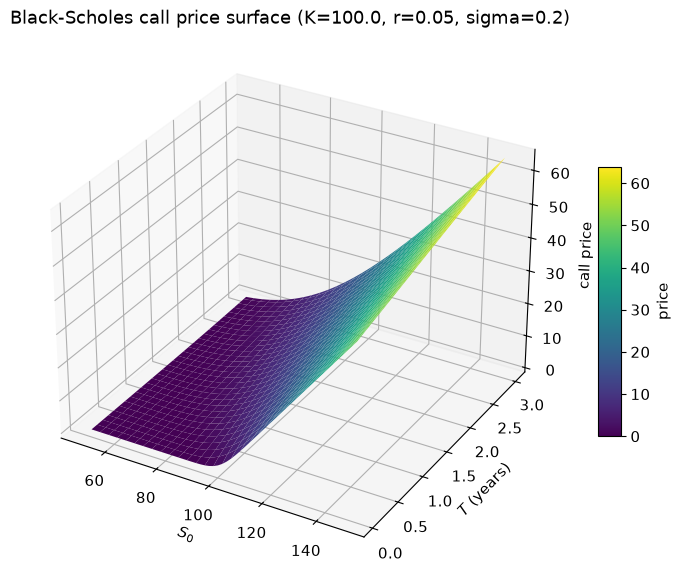

In [3]:
S_grid = np.linspace(50, 150, 60)
T_grid = np.linspace(0.05, 3.0, 60)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
price_mesh = bs_price(S_mesh, K, r, q, sigma, T_mesh, kind="call")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_mesh, T_mesh, price_mesh, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("$S_0$")
ax.set_ylabel("$T$ (years)")
ax.set_zlabel("call price")
ax.set_title(f"Black-Scholes call price surface (K={K}, r={r}, sigma={sigma})")
fig.colorbar(surf, shrink=0.5, aspect=12, label="price")
plt.show()

La superficie es monótona creciente en $S_0$ para todo $T$ (delta $=e^{-qT}N(d_1)\in(0,1)$, Sección 2.4) y también creciente en $T$ (más varianza acumulada = más valor de opcionalidad) — consistente con la interpretación de $N(d_1),N(d_2)$ como probabilidades bajo distintas medidas: ambas crecen con $T$ para $S_0$ fijo cerca o por encima de $K$, empujando el precio hacia arriba.

## 5. Demo 2 — Verificación Monte Carlo (3 SE)

Simulamos $S_T$ bajo $\mathbb{Q}$ directamente de la fórmula cerrada de la Sección 2.1 (sin discretizar la SDE: la solución exacta del GBM es exacta en un solo paso), promediamos el payoff descontado, y comparamos contra `bs_price` dentro de $\pm 3$ errores estándar Monte Carlo — el mismo criterio de 04.1/01.4.

In [4]:
n_mc = 200_000
Z = rng.standard_normal(n_mc)
ST = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
payoff = np.maximum(ST - K, 0.0)
disc_payoff = np.exp(-r * T) * payoff

mc_price = disc_payoff.mean()
mc_se = disc_payoff.std(ddof=1) / np.sqrt(n_mc)
closed_form = bs_price(S0, K, r, q, sigma, T, kind="call")

print(f"bs_price (closed form)      = {closed_form:.6f}")
print(f"Monte Carlo estimate        = {mc_price:.6f}  (SE = {mc_se:.6f}, n = {n_mc:,})")
print(f"|MC - closed form|          = {abs(mc_price - closed_form):.6f}")
print(f"3 * SE                      = {3 * mc_se:.6f}")

np.testing.assert_allclose(mc_price, closed_form, atol=3 * mc_se)
print("\nValidacion interna: closed form dentro de 3 SE del estimador Monte Carlo.")

bs_price (closed form)      = 10.450584
Monte Carlo estimate        = 10.463414  (SE = 0.033118, n = 200,000)
|MC - closed form|          = 0.012830
3 * SE                      = 0.099353

Validacion interna: closed form dentro de 3 SE del estimador Monte Carlo.


## 6. Demo 3 — Paridad put-call numérica

Verificamos $C-P=S_0e^{-qT}-Ke^{-rT}$ (Sección 2.4) sobre una rejilla de strikes, a precisión de máquina (no depende de simulación).

In [5]:
Ks = np.array([70, 85, 100, 115, 130], dtype=float)
calls = bs_price(S0, Ks, r, q, sigma, T, kind="call")
puts = bs_price(S0, Ks, r, q, sigma, T, kind="put")
lhs = calls - puts
rhs = S0 * np.exp(-q * T) - Ks * np.exp(-r * T)

print(f"{'K':>7} | {'C - P':>12} | {'S0*e^-qT - K*e^-rT':>20} | {'diff':>10}")
print("-" * 58)
for k_, l_, r_ in zip(Ks, lhs, rhs):
    print(f"{k_:>7.1f} | {l_:>12.6f} | {r_:>20.6f} | {abs(l_ - r_):>10.2e}")

np.testing.assert_allclose(lhs, rhs, atol=1e-10)
print("\nValidacion interna: paridad put-call exacta (atol=1e-10) para todos los strikes.")

      K |        C - P |   S0*e^-qT - K*e^-rT |       diff
----------------------------------------------------------
   70.0 |    33.413940 |            33.413940 |   7.11e-15
   85.0 |    19.145499 |            19.145499 |   7.11e-15
  100.0 |     4.877058 |             4.877058 |   0.00e+00
  115.0 |    -9.391384 |            -9.391384 |   0.00e+00
  130.0 |   -23.659825 |           -23.659825 |   3.55e-15

Validacion interna: paridad put-call exacta (atol=1e-10) para todos los strikes.


## 7. Validación

Comparamos `bs_price` contra `QuantLib` (`AnalyticEuropeanEngine`, la fórmula cerrada exacta que `QuantLib` implementa para procesos `BlackScholesMertonProcess`) sobre la malla completa $K\in\{80,90,100,110,120\}\times T\in\{0.25,1,5\}$, calls y puts — 30 combinaciones en total. Mismo setup de `QuantLib` que 2.2/2.4: fecha de evaluación fija, `Actual365Fixed`, curvas planas continuas. Como `Actual365Fixed` cuenta días calendario, fijamos la madurez como un número entero de días y usamos el `T` **exacto** (`yearFraction`) resultante en `bs_price` — así ambos lados de la comparación usan idénticamente el mismo tiempo a vencimiento, y la tolerancia de $10^{-10}$ solo mide diferencia de fórmula, no de convención de calendario.

In [6]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()

r_val, q_val, sigma_val = 0.05, 0.02, 0.20
S0_val = 100.0
strikes = [80.0, 90.0, 100.0, 110.0, 120.0]
T_targets = [0.25, 1.0, 5.0]

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0_val))
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r_val, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q_val, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma_val, day_count))
process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)
engine = ql.AnalyticEuropeanEngine(process)

rows = []
max_diff = 0.0
for T_target in T_targets:
    maturity = eval_date + int(round(T_target * 365))
    T_actual = day_count.yearFraction(eval_date, maturity)
    for K_val in strikes:
        for kind, ql_kind in [("call", ql.Option.Call), ("put", ql.Option.Put)]:
            payoff = ql.PlainVanillaPayoff(ql_kind, K_val)
            exercise = ql.EuropeanExercise(maturity)
            option = ql.VanillaOption(payoff, exercise)
            option.setPricingEngine(engine)
            ql_price = option.NPV()

            py_price = bs_price(S0_val, K_val, r_val, q_val, sigma_val, T_actual, kind=kind)
            diff = abs(py_price - ql_price)
            max_diff = max(max_diff, diff)
            rows.append((T_target, K_val, kind, ql_price, py_price, diff))

print(f"{'T':>5} | {'K':>6} | {'kind':>4} | {'QuantLib':>14} | {'bs_price':>14} | {'diff':>10}")
print("-" * 68)
for T_target, K_val, kind, ql_price, py_price, diff in rows:
    print(f"{T_target:>5.2f} | {K_val:>6.1f} | {kind:>4} | {ql_price:>14.10f} | {py_price:>14.10f} | {diff:>10.2e}")

print(f"\nmax |bs_price - QuantLib| sobre {len(rows)} combinaciones (K x T x kind) = {max_diff:.3e}")

for _, _, _, ql_price, py_price, _ in rows:
    np.testing.assert_allclose(py_price, ql_price, atol=1e-10)
print("Validacion contra QuantLib: todas las 30 combinaciones dentro de atol=1e-10.")

    T |      K | kind |       QuantLib |       bs_price |       diff
--------------------------------------------------------------------
 0.25 |   80.0 | call |  20.5251890856 |  20.5251890856 |   3.55e-15
 0.25 |   80.0 |  put |   0.0315079046 |   0.0315079046 |   5.71e-15
 0.25 |   90.0 | call |  11.2242561674 |  11.2242561674 |   1.78e-15
 0.25 |   90.0 |  put |   0.6066912088 |   0.6066912088 |   9.44e-15
 0.25 |  100.0 | call |   4.3295109080 |   4.3295109080 |   2.66e-15
 0.25 |  100.0 |  put |   3.5880621717 |   3.5880621717 |   4.44e-16
 0.25 |  110.0 | call |   1.0816621486 |   1.0816621486 |   2.44e-15
 0.25 |  110.0 |  put |  10.2163296345 |  10.2163296345 |   1.07e-14
 0.25 |  120.0 | call |   0.1748734127 |   0.1748734127 |   3.89e-16
 0.25 |  120.0 |  put |  19.1856571210 |  19.1856571210 |   7.11e-15
 1.00 |   80.0 | call |  22.7641254538 |  22.7641254538 |   2.84e-14
 1.00 |   80.0 |  put |   0.8426120832 |   0.8426120832 |   1.78e-15
 1.00 |   90.0 | call |  15.123708

## Referencias

- Black, F. & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637-654.
- Merton, R.C. (1973). *Theory of Rational Option Pricing*. Bell Journal of Economics and Management Science, 4(1), 141-183.
- Shreve, S. (2004). *Stochastic Calculus for Finance II: Continuous-Time Models*, cap. 4-5.
- Björk, T. (2009). *Arbitrage Theory in Continuous Time*, 3rd ed. Oxford University Press, cap. 7-8.
- Wilmott, P. (2006). *Paul Wilmott on Quantitative Finance*, 2nd ed. Wiley, cap. 5 (reducción a la ecuación del calor).